# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot, plot_ppc

## Configuration

In [2]:
az.rcParams["data.load"] = "eager"

## BFI analysis

In [3]:
msts_bfi_vehicle = pl.read_csv(PREPARED_FILES["bfi_vehicle"])
msts_bfi_empa = pl.read_csv(PREPARED_FILES["bfi_empa"])
msts_bfi_vehicle.describe()

statistic,,rat,gtyp,age,sex,vessel_idx,treatment,bfi_baseline,bfi_change,bfi_injected,log_bfi_baseline,log_bfi_injected,log_bfi_baseline_std,log_bfi_change
str,f64,str,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64
"""count""",763.0,"""763""","""763""","""763""","""763""",763.0,"""763""",763.0,763.0,763.0,763.0,763.0,763.0,763.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",396.760157,null,null,null,null,12.087811,null,60.508247,3.396842,63.905089,4.082197,4.135394,-0.087787,0.053196
"""std""",225.030033,null,null,null,null,8.071947,null,12.346811,3.832176,13.554967,0.203315,0.209763,0.978514,0.059407
"""min""",15.0,"""20240813a""","""fa/+""","""Adult""","""F""",0.0,"""Vehicle""",29.043812,-7.538559,33.834568,3.368805,3.521483,-3.521196,-0.11578
"""25%""",205.0,null,null,null,null,5.0,null,50.708885,0.664391,53.904743,3.926101,3.987218,-0.839046,0.011429
"""50%""",385.0,null,null,null,null,11.0,null,59.074081,3.135319,61.920944,4.078792,4.125858,-0.104175,0.051714
"""75%""",589.0,null,null,null,null,18.0,null,68.218925,6.059395,72.643837,4.222722,4.285569,0.588529,0.098368
"""max""",825.0,"""20241030b""","""fa/fa""","""Young""","""M""",33.0,"""Vehicle""",102.490929,20.555809,109.41053,4.629774,4.695107,2.547588,0.251871


In [4]:
idata_bfi_empa = az.from_netcdf(RESULTS_DIR / "idata_bfi_empa.nc")
idata_bfi_vehicle = az.from_netcdf(RESULTS_DIR / "idata_bfi_vehicle.nc")
idata_bfi_baseline = az.from_netcdf(RESULTS_DIR / "idata_bfi_baseline.nc")
idata_bfi_baseline_extra_interaction = az.from_netcdf(RESULTS_DIR / "idata_bfi_baseline_extra_interaction.nc")

idata_bfi_empa

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [36]:
print("BFI empa:")
display(az.summary(idata_bfi_empa, var_names=["~mu", "~1|rat"]))
print("BFI vehicle:")
display(az.summary(idata_bfi_vehicle, var_names=["~mu", "~1|rat"]))
print("BFI baseline:")
display(az.summary(idata_bfi_baseline, var_names=["~mu", "~1|rat"]))
print("BFI baseline extra interaction:")
display(az.summary(idata_bfi_baseline_extra_interaction, var_names=["~mu", "~1|rat"]))

BFI empa:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.025,0.001,0.024,0.026,0.000,0.000,3186.0,2464.0,1.0
Intercept,-0.159,0.022,-0.201,-0.119,0.001,0.000,1473.0,1652.0,1.0
gtyp[fa/fa],0.083,0.033,0.022,0.145,0.001,0.001,1573.0,1507.0,1.0
age[Young],0.016,0.031,-0.044,0.076,0.001,0.001,1650.0,1322.0,1.0
sex[M],-0.031,0.031,-0.089,0.027,0.001,0.001,1537.0,1653.0,1.0
"gtyp:age[fa/fa, Young]",-0.036,0.043,-0.122,0.041,0.001,0.001,1647.0,1430.0,1.0
"gtyp:sex[fa/fa, M]",0.019,0.042,-0.059,0.099,0.001,0.001,1683.0,1733.0,1.0
1|rat_sigma,0.061,0.009,0.044,0.077,0.000,0.000,942.0,1439.0,1.0


BFI vehicle:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.023,0.001,0.022,0.024,0.000,0.000,3100.0,2785.0,1.00
Intercept,0.086,0.018,0.053,0.119,0.001,0.000,1147.0,1342.0,1.00
gtyp[fa/fa],-0.023,0.027,-0.072,0.032,0.001,0.001,1395.0,1483.0,1.00
age[Young],0.032,0.026,-0.014,0.082,0.001,0.001,1552.0,1349.0,1.00
sex[M],-0.097,0.026,-0.144,-0.046,0.001,0.001,1481.0,1380.0,1.00
"gtyp:age[fa/fa, Young]",-0.031,0.036,-0.096,0.038,0.001,0.001,1468.0,1573.0,1.00
"gtyp:sex[fa/fa, M]",0.066,0.037,-0.008,0.130,0.001,0.001,1491.0,1451.0,1.01
1|rat_sigma,0.050,0.007,0.037,0.064,0.000,0.000,1035.0,1492.0,1.00


BFI baseline:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.110,0.003,0.104,0.115,0.000,0.000,2879.0,2479.0,1.0
Intercept,4.184,0.054,4.080,4.284,0.002,0.001,1178.0,1546.0,1.0
gtyp[fa/fa],-0.294,0.083,-0.451,-0.141,0.002,0.002,1450.0,1633.0,1.0
age[Young],-0.141,0.084,-0.293,0.020,0.002,0.002,1483.0,1871.0,1.0
sex[M],-0.028,0.077,-0.172,0.117,0.002,0.002,1348.0,1443.0,1.0
"gtyp:age[fa/fa, Young]",0.184,0.115,-0.019,0.412,0.003,0.002,1586.0,1778.0,1.0
"gtyp:sex[fa/fa, M]",0.274,0.107,0.069,0.465,0.003,0.002,1392.0,1658.0,1.0
1|rat_sigma,0.156,0.023,0.114,0.196,0.001,0.001,1045.0,1835.0,1.0


BFI baseline extra interaction:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.110,0.003,0.104,0.115,0.000,0.000,3922.0,2367.0,1.0
Intercept,4.229,0.058,4.120,4.341,0.001,0.001,1783.0,1748.0,1.0
gtyp[fa/fa],-0.336,0.090,-0.513,-0.176,0.002,0.002,1708.0,1870.0,1.0
age[Young],-0.339,0.119,-0.561,-0.115,0.003,0.002,2125.0,2136.0,1.0
sex[M],-0.150,0.097,-0.321,0.034,0.002,0.002,1980.0,1665.0,1.0
"gtyp:age[fa/fa, Young]",0.382,0.155,0.072,0.658,0.004,0.003,1718.0,1807.0,1.0
"gtyp:sex[fa/fa, M]",0.397,0.143,0.148,0.687,0.003,0.003,2087.0,2185.0,1.0
"gtyp:age:sex[fa/+, Young, M]",0.356,0.162,0.042,0.654,0.003,0.003,2181.0,2194.0,1.0
"gtyp:age:sex[fa/fa, Young, M]",-0.004,0.150,-0.279,0.287,0.003,0.003,2289.0,2306.0,1.0
1|rat_sigma,0.148,0.023,0.108,0.190,0.001,0.000,1357.0,1657.0,1.0


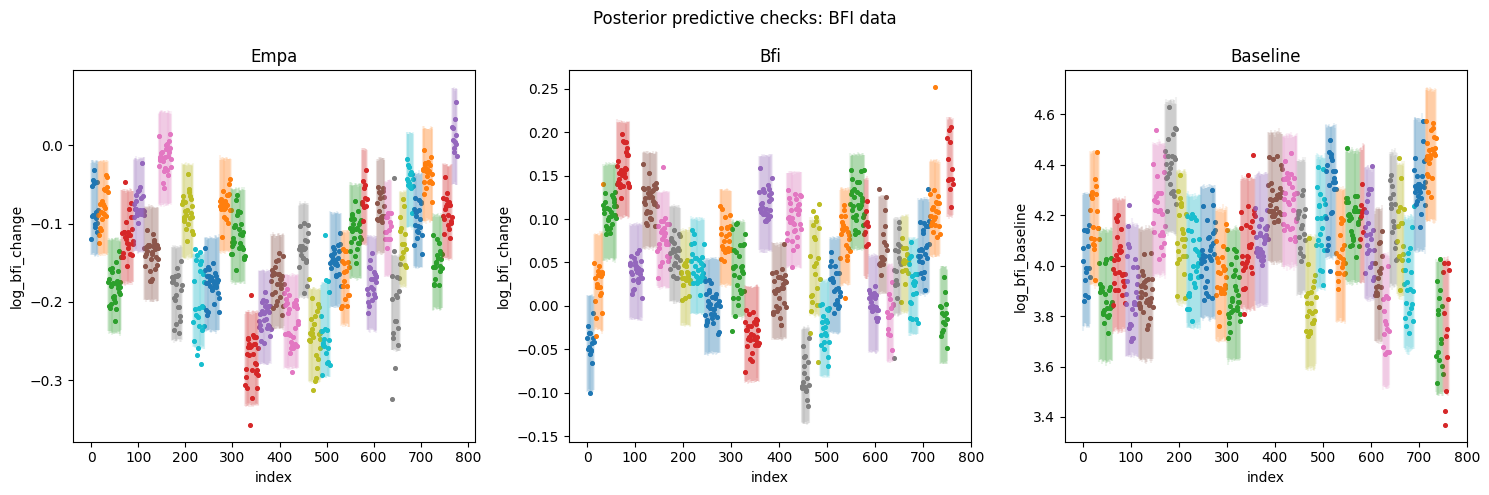

In [6]:
f, axes = plt.subplots(1, 3, figsize=[15, 5], sharey=False)
for ax, idata, name, msts, ycol, in zip(
    axes, 
    (idata_bfi_empa, idata_bfi_vehicle, idata_bfi_baseline_extra_interaction), 
    ("empa", "bfi", "baseline"),
    (msts_bfi_empa, msts_bfi_vehicle, msts_bfi_vehicle),
    ("log_bfi_change", "log_bfi_change", "log_bfi_baseline"),
):
    ax = plot_ppc(ax, idata, msts, ycol=ycol, groupcol="rat")
    ax.set_title(name.capitalize());
    ax.get_legend().remove()

f.suptitle("Posterior predictive checks: BFI data");
f.tight_layout()
f.savefig(PLOT_DIR / "ppc_bfi.png", bbox_inches="tight", dpi=200)

In [7]:
az.compare(
    {
        "default": idata_bfi_baseline, 
        "extra_interaction": idata_bfi_baseline_extra_interaction
    }
)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
extra_interaction,0,582.684059,35.073991,0.000000,1.0,20.956766,0.000000,False,log
default,1,582.368097,35.418301,0.315962,0.0,20.989840,0.343951,False,log


In [32]:
t = (
    idata_bfi_baseline.log_likelihood["log_bfi_baseline"]
- idata_bfi_baseline_extra_interaction.log_likelihood["log_bfi_baseline"]
)
msts_bfi_vehicle.with_columns(ll_diff=t.mean(dim=["chain", "draw"]).to_numpy().flatten()).sort("ll_diff").head()

,rat,gtyp,age,sex,vessel_idx,treatment,bfi_baseline,bfi_change,bfi_injected,log_bfi_baseline,log_bfi_injected,log_bfi_baseline_std,log_bfi_change,ll_diff
i64,str,str,str,str,i64,str,f64,f64,f64,f64,f64,f64,f64,f64
293,"""20241015b""","""fa/+""","""Adult""","""M""",4,"""Vehicle""",50.471996,-0.932301,49.539696,3.921419,3.902774,-0.861582,-0.018644,-0.05402
710,"""20240826a""","""fa/+""","""Young""","""M""",5,"""Vehicle""",84.579727,-2.995056,81.584671,4.437695,4.401641,1.623148,-0.036053,-0.04573
292,"""20241015b""","""fa/+""","""Adult""","""M""",3,"""Vehicle""",53.472725,-0.165295,53.30743,3.979172,3.976076,-0.583629,-0.003096,-0.041757
287,"""20241015b""","""fa/+""","""Adult""","""M""",17,"""Vehicle""",53.610363,-2.194973,51.41539,3.981742,3.939938,-0.571256,-0.041805,-0.041209
323,"""20240820a""","""fa/+""","""Young""","""M""",15,"""Vehicle""",93.332573,4.394821,97.727394,4.536169,4.582182,2.097086,0.046013,-0.040075


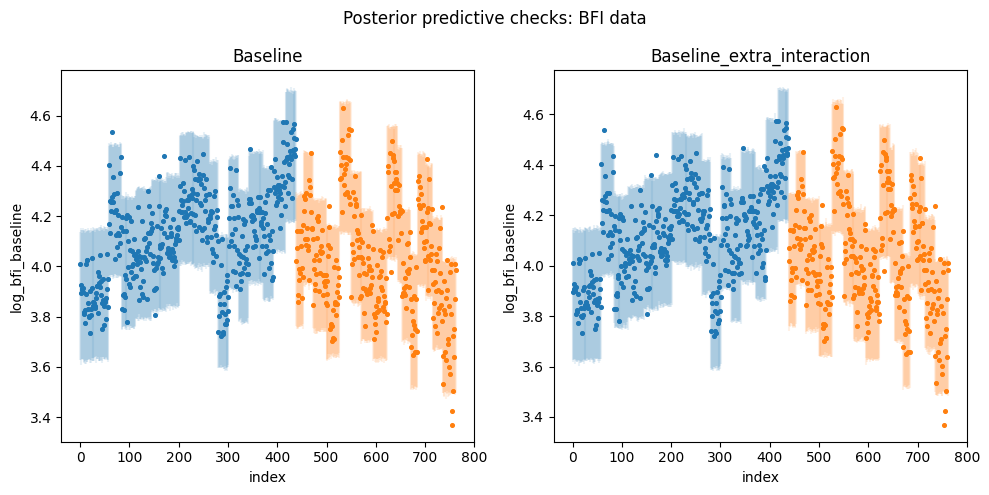

In [35]:
f, axes = plt.subplots(1, 2, figsize=[10, 5], sharey=False)
for ax, idata, name, msts, ycol, in zip(
    axes, 
    (idata_bfi_baseline, idata_bfi_baseline_extra_interaction), 
    ("baseline", "baseline_extra_interaction"),
    (msts_bfi_vehicle, msts_bfi_vehicle),
    ("log_bfi_baseline", "log_bfi_baseline"),
):
    ax = plot_ppc(ax, idata, msts, ycol=ycol, groupcol="gtyp")
    ax.scatter()
    ax.set_title(name.capitalize());
    ax.get_legend().remove()

f.suptitle("Posterior predictive checks: BFI data");
f.tight_layout()


In [10]:
t_groups_empa, t_groups_vehicle = (
    {
        "fa/fa:young": idata.posterior["age"] + idata.posterior["gtyp"] + idata.posterior["gtyp:age"],
        "fa/fa:old": idata.posterior["gtyp"],
        "fa/+:old": 0.0,
        "fa/+:young": idata.posterior["age"],    
    } 
    for idata in (idata_bfi_empa, idata_bfi_vehicle)
)
ts_empa, ts_vehicle = (
    {
        "fa/fa given young": t_groups["fa/fa:young"] - t_groups["fa/+:young"],
        "fa/fa given old": t_groups["fa/fa:old"] - t_groups["fa/+:old"],
        "young given fa/fa": t_groups["fa/fa:young"] - t_groups["fa/fa:old"],
        "young given fa/+": t_groups["fa/+:young"] - t_groups["fa/+:old"],
    }
    for t_groups in (t_groups_empa, t_groups_vehicle)
)
def get_sign_probs(ts):
    return {k: (v>0).mean().item() for k, v in ts.items()}

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa given young': 0.88625,
 'fa/fa given old': 0.99475,
 'young given fa/fa': 0.2505,
 'young given fa/+': 0.70275}


Vehicle sign probabilities:


{'fa/fa given young': 0.0615,
 'fa/fa given old': 0.2015,
 'young given fa/fa': 0.53125,
 'young given fa/+': 0.89025}

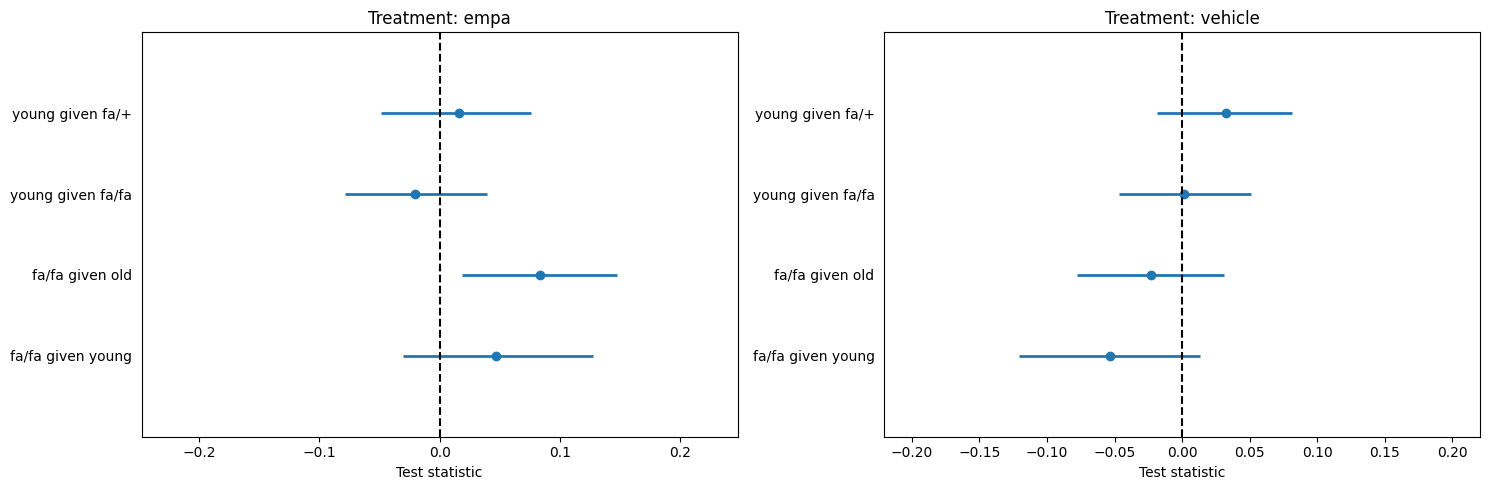

In [11]:
f, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0] = forestplot(axes[0], ts_empa);
axes[0].set_title("Treatment: empa");

axes[1] = forestplot(axes[1], ts_vehicle);
axes[1].set_title("Treatment: vehicle");

f.tight_layout()
f.savefig(PLOT_DIR / "ts_bfi.png", bbox_inches="tight", dpi=200)

## Frequency

In [12]:
msts_frequency = pl.read_csv(PREPARED_FILES["frequency"])
msts_frequency.describe()

statistic,,rat,gtyp,age,sex,vessel_idx,frequency_empa,frequency_vehicle,frequency_change,frequency_vehicle_std,frequency_empa_std,frequency_change_std,log_frequency_vehicle,log_frequency_empa,log_frequency_vehicle_std,log_frequency_change
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",229.0,"""229""","""229""","""229""","""229""",229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",285.279476,null,null,null,null,12.218341,0.029575,0.026958,0.002617,-3.7234e-16,1.2411e-16,-6.2056e-17,-3.624209,-3.533741,-4.5301e-15,0.090468
"""std""",158.105563,null,null,null,null,7.719048,0.0045,0.00384,0.002757,1.0,1.0,1.0,0.149548,0.166347,1.0,0.102385
"""min""",3.0,"""20240814a""","""fa/+""","""Adult""","""F""",0.0,0.015708,0.015634,-0.011551,-2.949113,-3.081311,-5.138784,-4.158299,-4.153608,-3.571348,-0.436914
"""25%""",130.0,null,null,null,null,6.0,0.026423,0.024266,0.001281,-0.70094,-0.700319,-0.484396,-3.718664,-3.633521,-0.6316,0.045953
"""50%""",287.0,null,null,null,null,12.0,0.02996,0.026984,0.002494,0.006762,0.085685,-0.044437,-3.612522,-3.507883,0.07815,0.086278
"""75%""",428.0,null,null,null,null,17.0,0.032916,0.029501,0.003881,0.662343,0.742474,0.458477,-3.523334,-3.413794,0.674533,0.133595
"""max""",537.0,"""20241030b""","""fa/fa""","""Young""","""M""",33.0,0.038459,0.036252,0.013356,2.420488,1.974127,3.895263,-3.317272,-3.258164,2.052429,0.46905


In [13]:
idata_frequency = az.from_netcdf(RESULTS_DIR / "idata_frequency.nc")
idata_frequency_baseline = az.from_netcdf(RESULTS_DIR / "idata_frequency_baseline.nc")
idata_frequency

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [14]:
print("Frequency:")
display(az.summary(idata_frequency, var_names=["~mu", "~1|rat"]))
print("Frequency baseline:")
display(az.summary(idata_frequency_baseline, var_names=["~mu", "~1|rat"]))

Frequency:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.001,0.000,0.001,0.002,0.0,0.0,3876.0,2876.0,1.0
Intercept,0.004,0.001,0.002,0.005,0.0,0.0,1931.0,2135.0,1.0
gtyp[fa/fa],-0.002,0.001,-0.004,0.001,0.0,0.0,2038.0,2271.0,1.0
age[Young],-0.001,0.002,-0.005,0.002,0.0,0.0,2347.0,2114.0,1.0
sex[M],0.001,0.002,-0.002,0.004,0.0,0.0,2415.0,2394.0,1.0
"gtyp:age[fa/fa, Young]",0.003,0.002,-0.001,0.007,0.0,0.0,2325.0,2469.0,1.0
"gtyp:sex[fa/fa, M]",-0.007,0.002,-0.011,-0.003,0.0,0.0,2303.0,2163.0,1.0
1|rat_sigma,0.002,0.000,0.001,0.003,0.0,0.0,1318.0,2166.0,1.0


Frequency baseline:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.002,0.000,0.002,0.002,0.0,0.0,4392.0,2693.0,1.0
Intercept,0.028,0.001,0.025,0.030,0.0,0.0,1863.0,2064.0,1.0
gtyp[fa/fa],-0.004,0.002,-0.008,0.000,0.0,0.0,2018.0,2368.0,1.0
age[Young],-0.002,0.003,-0.008,0.003,0.0,0.0,2166.0,2219.0,1.0
sex[M],0.001,0.003,-0.005,0.006,0.0,0.0,2429.0,2412.0,1.0
"gtyp:age[fa/fa, Young]",0.006,0.004,-0.001,0.013,0.0,0.0,2411.0,2335.0,1.0
"gtyp:sex[fa/fa, M]",-0.001,0.004,-0.008,0.005,0.0,0.0,2314.0,2320.0,1.0
1|rat_sigma,0.004,0.001,0.002,0.005,0.0,0.0,1488.0,2090.0,1.0


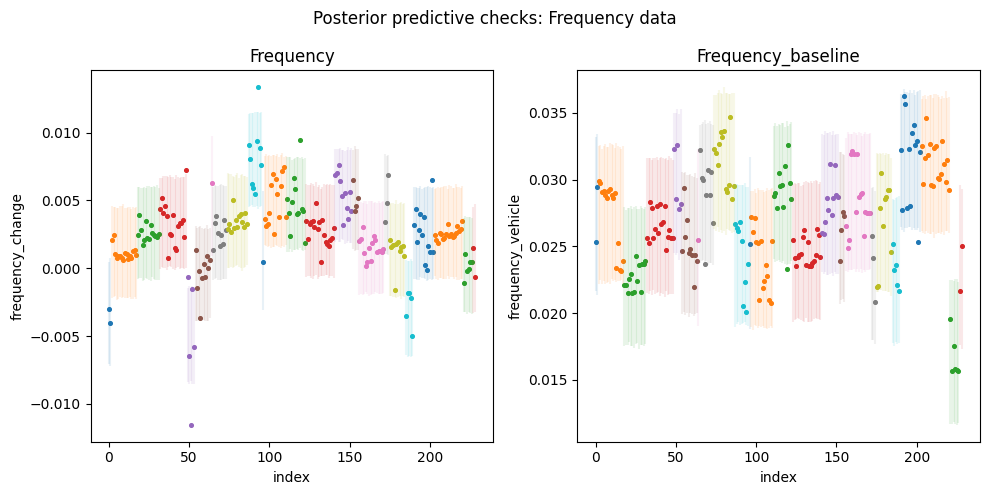

In [15]:
f, axes = plt.subplots(1, 2, figsize=[10, 5], sharey=False)
for ax, idata, name, msts, ycol, in zip(
    axes, 
    (idata_frequency, idata_frequency_baseline), 
    ("frequency", "frequency_baseline"),
    (msts_frequency, msts_frequency),
    ("frequency_change", "frequency_vehicle"),
):
    ax = plot_ppc(ax, idata, msts, ycol=ycol, groupcol="rat")
    ax.set_title(name.capitalize());
    ax.get_legend().remove()

f.suptitle("Posterior predictive checks: Frequency data");
f.tight_layout()
f.savefig(PLOT_DIR / "ppc_frequency.png", bbox_inches="tight", dpi=200)

In [16]:
t_groups_frequency = {
    "fa/fa:male": idata_frequency.posterior["gtyp"] + idata_frequency.posterior["sex"] + idata_frequency.posterior["gtyp:sex"],
    "fa/+:male": idata_frequency.posterior["sex"],
    "fa/fa:female": idata_frequency.posterior["gtyp"],
    "fa/+:female": 0.0,
    "fa/fa:young": idata_frequency.posterior["gtyp"] + idata_frequency.posterior["age"] + idata_frequency.posterior["gtyp:age"],
    "fa/+:young": idata_frequency.posterior["age"],    
    "fa/fa:old": idata_frequency.posterior["gtyp"],
    "fa/+:old": 0.0,
} 
ts_frequency = {
    "fa/fa given male": t_groups_frequency["fa/fa:male"] - t_groups_frequency["fa/+:male"],
    "fa/fa given female": t_groups_frequency["fa/fa:female"] - t_groups_frequency["fa/+:female"],
    "fa/fa given young": t_groups_frequency["fa/fa:young"] - t_groups_frequency["fa/+:young"],
    "fa/fa given old": t_groups_frequency["fa/fa:old"] - t_groups_frequency["fa/+:old"],
    "young given fa/fa": t_groups_frequency["fa/fa:young"] - t_groups_frequency["fa/fa:old"],
    "young given fa/+": t_groups_frequency["fa/+:young"] - t_groups_frequency["fa/+:old"],
}
print("Sign probabilities:")
display(get_sign_probs(ts_frequency))

Sign probabilities:


{'fa/fa given male': 0.0,
 'fa/fa given female': 0.07175,
 'fa/fa given young': 0.76125,
 'fa/fa given old': 0.07175,
 'young given fa/fa': 0.9135,
 'young given fa/+': 0.1895}

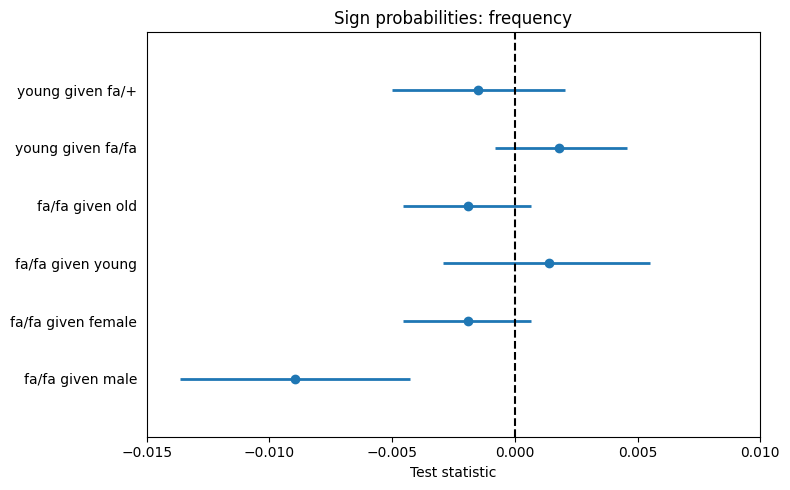

In [17]:
f, ax = plt.subplots(figsize=(8, 5))
ax = forestplot(ax, ts_frequency);
ax.set_title("Sign probabilities: frequency");
ax.set_xlim(-0.015, 0.01)
f.tight_layout()
f.savefig(PLOT_DIR / "ts_frequency.png", bbox_inches="tight", dpi=200)

## Power

In [18]:
msts_power = pl.read_csv(PREPARED_FILES["power"])
msts_power.describe()

statistic,,rat,gtyp,age,sex,vessel_idx,power_empa,power_vehicle,power_ratio,power_change,power_vehicle_std,power_empa_std,power_change_std,log_power_vehicle,log_power_empa,log_power_vehicle_std,log_power_change
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",725.0,"""725""","""725""","""725""","""725""",725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",396.801379,null,null,null,null,11.944828,8.160552,17.184354,0.565412,-9.023802,2.5482e-16,9.8006e-17,1.5681e-16,2.490881,1.737094,-3.9202e-16,-0.753787
"""std""",231.511468,null,null,null,null,7.94315,8.155119,16.899861,0.325091,12.873524,1.0,1.0,1.0,0.8342,0.845396,1.0,0.666469
"""min""",0.0,"""20240813a""","""fa/+""","""Adult""","""F""",0.0,0.521412,1.606238,0.024145,-113.020245,-0.92179,-0.936729,-8.07832,0.473895,-0.651215,-2.41787,-3.723676
"""25%""",199.0,null,null,null,null,5.0,3.059968,6.680392,0.349868,-11.218514,-0.621541,-0.625446,-0.170483,1.899177,1.118404,-0.709308,-1.0502
"""50%""",392.0,null,null,null,null,11.0,5.595548,11.82154,0.52548,-5.423467,-0.317329,-0.314527,0.27967,2.469923,1.721971,-0.025123,-0.643442
"""75%""",590.0,null,null,null,null,18.0,10.600946,21.514314,0.717233,-2.104147,0.256213,0.299247,0.537511,3.068718,2.360943,0.692685,-0.332355
"""max""",815.0,"""20241030b""","""fa/fa""","""Young""","""M""",33.0,68.914547,118.211847,2.68275,7.781855,5.978007,7.449798,1.305443,4.772478,4.232867,2.735074,0.986843


In [19]:
idata_power = az.from_netcdf(RESULTS_DIR / "idata_power.nc")
idata_power_baseline = az.from_netcdf(RESULTS_DIR / "idata_power_baseline.nc")
idata_power

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [20]:
print("Power:")
display(az.summary(idata_power, var_names=["~mu", "~1|rat"]))
print("Power baseline:")
display(az.summary(idata_power_baseline, var_names=["~mu", "~1|rat"]))

Power:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.440,0.012,0.417,0.460,0.000,0.000,3813.0,2397.0,1.0
Intercept,-0.660,0.169,-0.977,-0.350,0.005,0.004,1366.0,1792.0,1.0
gtyp[fa/fa],0.163,0.259,-0.332,0.644,0.006,0.006,1577.0,1704.0,1.0
age[Young],-0.051,0.254,-0.533,0.421,0.006,0.005,1708.0,2041.0,1.0
sex[M],-0.546,0.241,-0.974,-0.062,0.006,0.005,1603.0,1860.0,1.0
"gtyp:age[fa/fa, Young]",0.121,0.350,-0.530,0.781,0.009,0.006,1601.0,1914.0,1.0
"gtyp:sex[fa/fa, M]",0.524,0.336,-0.110,1.179,0.008,0.006,1634.0,1853.0,1.0
1|rat_sigma,0.469,0.069,0.354,0.603,0.002,0.001,1154.0,1893.0,1.0


Power baseline:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.548,0.015,0.520,0.575,0.000,0.000,3426.0,2779.0,1.00
Intercept,2.943,0.219,2.549,3.358,0.006,0.005,1150.0,1364.0,1.00
gtyp[fa/fa],-0.394,0.322,-0.970,0.266,0.010,0.007,1132.0,1485.0,1.00
age[Young],-0.435,0.336,-1.086,0.192,0.009,0.007,1407.0,1722.0,1.00
sex[M],-0.338,0.327,-0.956,0.280,0.010,0.007,1140.0,1332.0,1.00
"gtyp:age[fa/fa, Young]",0.445,0.441,-0.430,1.233,0.012,0.009,1435.0,1885.0,1.00
"gtyp:sex[fa/fa, M]",-0.365,0.427,-1.217,0.398,0.012,0.010,1235.0,1490.0,1.00
1|rat_sigma,0.614,0.091,0.452,0.782,0.003,0.002,987.0,1645.0,1.01


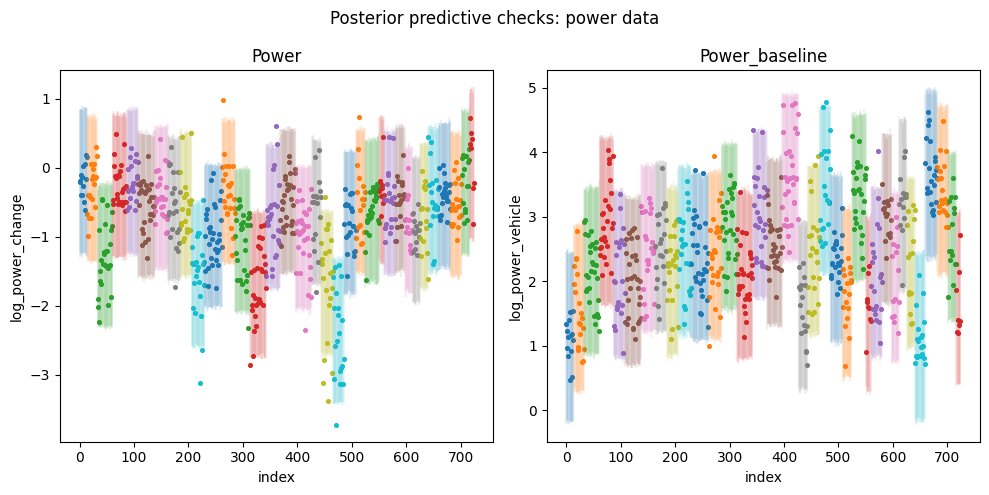

In [21]:
f, axes = plt.subplots(1, 2, figsize=[10, 5], sharey=False)
for ax, idata, name, msts, ycol, in zip(
    axes, 
    (idata_power, idata_power_baseline), 
    ("power", "power_baseline"),
    (msts_power, msts_power),
    ("log_power_change", "log_power_vehicle"),
):
    ax = plot_ppc(ax, idata, msts, ycol=ycol, groupcol="rat")
    ax.set_title(name.capitalize());
    ax.get_legend().remove()

f.suptitle("Posterior predictive checks: power data");
f.tight_layout()
f.savefig(PLOT_DIR / "ppc_power.png", bbox_inches="tight", dpi=200)

In [22]:
t_groups_power = {
    "fa/fa:male": idata_power.posterior["gtyp"] + idata_power.posterior["sex"] + idata_power.posterior["gtyp:sex"],
    "fa/+:male": idata_power.posterior["sex"],
    "fa/fa:female": idata_power.posterior["gtyp"],
    "fa/+:female": 0.0,
    "fa/fa:young": idata_power.posterior["gtyp"] + idata_power.posterior["age"] + idata_power.posterior["gtyp:age"],
    "fa/+:young": idata_power.posterior["age"],    
    "fa/fa:old": idata_power.posterior["gtyp"],
    "fa/+:old": 0.0,
} 
ts_power = {
    "fa/fa given male": t_groups_power["fa/fa:male"] - t_groups_power["fa/+:male"],
    "fa/fa given female": t_groups_power["fa/fa:female"] - t_groups_power["fa/+:female"],
    "fa/fa given young": t_groups_power["fa/fa:young"] - t_groups_power["fa/+:young"],
    "fa/fa given old": t_groups_power["fa/fa:old"] - t_groups_power["fa/+:old"],
    "young given fa/fa": t_groups_power["fa/fa:young"] - t_groups_power["fa/fa:old"],
    "young given fa/+": t_groups_power["fa/+:young"] - t_groups_power["fa/+:old"],
}
print("Sign probabilities:")
display(get_sign_probs(ts_power))


Sign probabilities:


{'fa/fa given male': 0.98375,
 'fa/fa given female': 0.74525,
 'fa/fa given young': 0.81825,
 'fa/fa given old': 0.74525,
 'young given fa/fa': 0.621,
 'young given fa/+': 0.42}

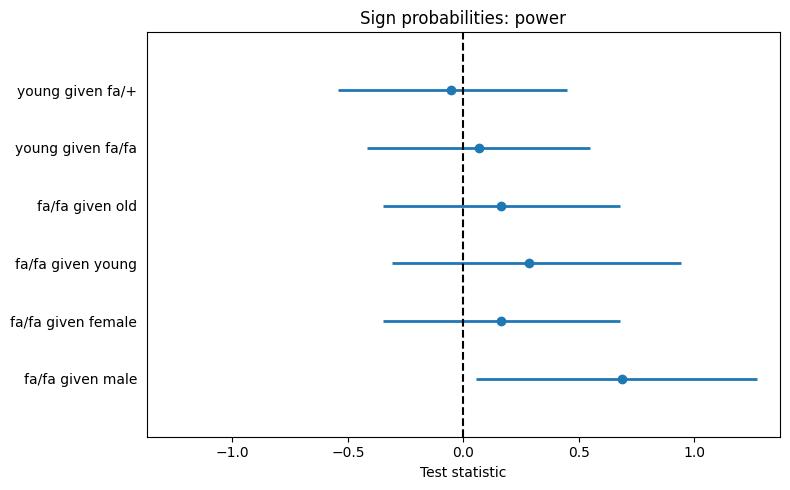

In [23]:
f, ax = plt.subplots(figsize=(8, 5))
ax = forestplot(ax, ts_power);
ax.set_title("Sign probabilities: power");
f.tight_layout()
f.savefig(PLOT_DIR / "ts_power.png", bbox_inches="tight", dpi=200)

## Blood pressure

In [24]:
msts_bp_vehicle = pl.read_csv(PREPARED_FILES["bp_vehicle"])
msts_bp_empa = pl.read_csv(PREPARED_FILES["bp_empa"])
msts_bp_vehicle.describe()

statistic,,rat,gtyp,age,sex,treatment,bp_baseline,bp_change,bp_injected,log_bp_baseline,log_bp_injected,log_bp_baseline_std,log_bp_change
str,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""",34.0,"""34""","""34""","""34""","""34""","""34""",34.0,34.0,34.0,34.0,34.0,34.0,34.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",403.058824,null,null,null,null,null,123.427017,3.935423,127.36244,4.813868,4.844778,-0.120778,0.03091
"""std""",233.659288,null,null,null,null,null,7.489972,5.255136,8.564283,0.060578,0.068773,0.773612,0.043617
"""min""",15.0,"""20240813a""","""fa/+""","""Adult""","""F""","""Vehicle""",109.07689,-11.98913,103.76452,4.692053,4.642124,-1.676413,-0.10934
"""25%""",202.0,null,null,null,null,null,116.84752,1.82411,121.22905,4.76087,4.797682,-0.797586,0.014409
"""50%""",412.0,null,null,null,null,null,123.03403,5.519496,128.25748,4.812461,4.85404,-0.13874,0.044119
"""75%""",594.0,null,null,null,null,null,128.9717,6.87104,134.86777,4.859593,4.904295,0.46316,0.053921
"""max""",814.0,"""20241030b""","""fa/fa""","""Young""","""M""","""Vehicle""",137.77512,12.7811,141.38322,4.925623,4.951474,1.306396,0.103804


In [25]:
idata_bp_empa = az.from_netcdf(RESULTS_DIR / "idata_bp_empa.nc")
idata_bp_vehicle = az.from_netcdf(RESULTS_DIR / "idata_bp_vehicle.nc")
idata_bp_baseline = az.from_netcdf(RESULTS_DIR / "idata_bp_baseline.nc")
idata_bp_empa

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [26]:
idata_bp_empa = az.from_netcdf(RESULTS_DIR / "idata_bp_empa.nc")
idata_bp_vehicle = az.from_netcdf(RESULTS_DIR / "idata_bp_vehicle.nc")
idata_bp_empa

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [27]:
print("bp empa:")
display(az.summary(idata_bp_empa, var_names=["~mu"]))
print("bp vehicle:")
display(az.summary(idata_bp_vehicle, var_names=["~mu"]))
print("bp baseline:")
display(az.summary(idata_bp_baseline, var_names=["~mu"]))

bp empa:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.038,0.005,0.029,0.048,0.000,0.0,3179.0,2965.0,1.0
Intercept,0.029,0.014,0.004,0.055,0.000,0.0,3058.0,2798.0,1.0
gtyp[fa/fa],-0.046,0.020,-0.082,-0.005,0.000,0.0,2445.0,2780.0,1.0
age[Young],0.001,0.020,-0.037,0.039,0.000,0.0,2396.0,2637.0,1.0
sex[M],-0.019,0.019,-0.054,0.017,0.000,0.0,2243.0,2177.0,1.0
"gtyp:age[fa/fa, Young]",0.019,0.027,-0.030,0.073,0.001,0.0,2266.0,2389.0,1.0
"gtyp:sex[fa/fa, M]",-0.041,0.026,-0.092,0.008,0.001,0.0,2502.0,2608.0,1.0


bp vehicle:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.045,0.006,0.035,0.056,0.000,0.0,2792.0,2639.0,1.0
Intercept,0.041,0.016,0.012,0.070,0.000,0.0,3449.0,3386.0,1.0
gtyp[fa/fa],0.009,0.024,-0.034,0.055,0.000,0.0,2636.0,2769.0,1.0
age[Young],0.003,0.024,-0.042,0.049,0.000,0.0,2708.0,2828.0,1.0
sex[M],-0.009,0.023,-0.052,0.032,0.000,0.0,2882.0,2715.0,1.0
"gtyp:age[fa/fa, Young]",-0.033,0.032,-0.091,0.027,0.001,0.0,2518.0,2710.0,1.0
"gtyp:sex[fa/fa, M]",-0.016,0.032,-0.076,0.043,0.001,0.0,2588.0,2978.0,1.0


bp baseline:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.060,0.008,0.046,0.075,0.000,0.000,2942.0,2582.0,1.0
Intercept,4.861,0.021,4.820,4.899,0.000,0.000,3403.0,2997.0,1.0
gtyp[fa/fa],-0.056,0.032,-0.116,0.005,0.001,0.001,2688.0,2732.0,1.0
age[Young],-0.030,0.031,-0.088,0.029,0.001,0.000,2639.0,2873.0,1.0
sex[M],-0.055,0.031,-0.107,0.010,0.001,0.001,2368.0,2247.0,1.0
"gtyp:age[fa/fa, Young]",0.020,0.042,-0.063,0.095,0.001,0.001,2626.0,2220.0,1.0
"gtyp:sex[fa/fa, M]",0.061,0.043,-0.020,0.141,0.001,0.001,2088.0,2500.0,1.0


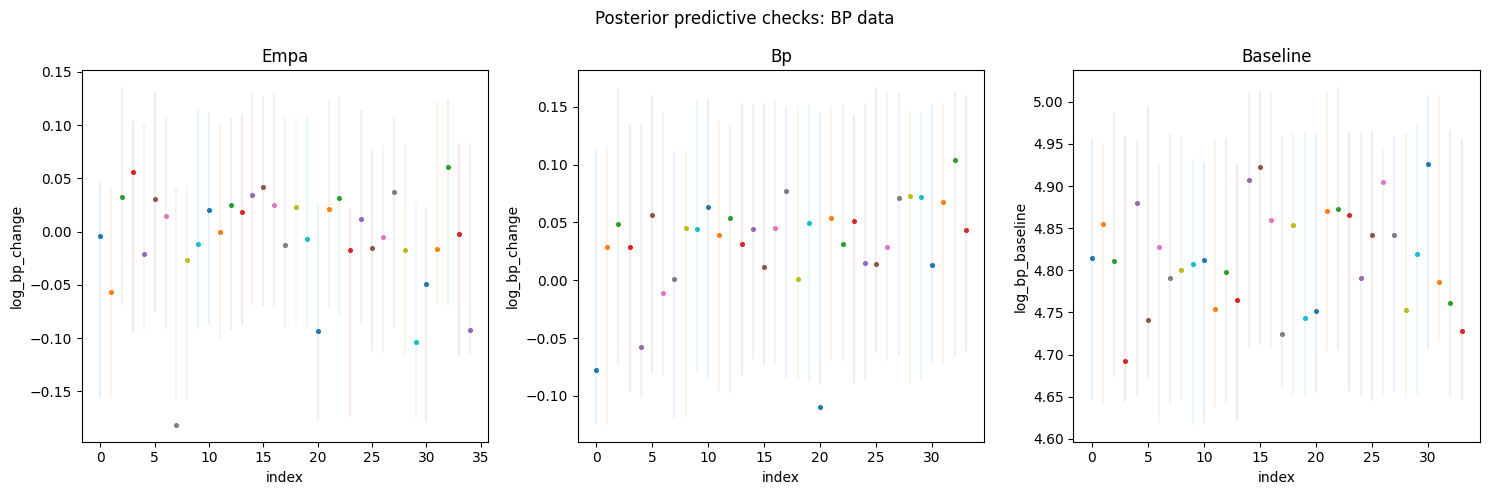

In [28]:
f, axes = plt.subplots(1, 3, figsize=[15, 5], sharey=False)
for ax, idata, name, msts, ycol, in zip(
    axes, 
    (idata_bp_empa, idata_bp_vehicle, idata_bp_baseline), 
    ("empa", "bp", "baseline"),
    (msts_bp_empa, msts_bp_vehicle, msts_bp_vehicle),
    ("log_bp_change", "log_bp_change", "log_bp_baseline"),
):
    ax = plot_ppc(ax, idata, msts, ycol=ycol, groupcol="rat")
    ax.set_title(name.capitalize());
    ax.get_legend().remove()

f.suptitle("Posterior predictive checks: BP data");
f.tight_layout()
f.savefig(PLOT_DIR / "ppc_bp.png", bbox_inches="tight", dpi=200)

In [29]:
t_groups_empa, t_groups_vehicle = (
    {
        "fa/fa:young": idata.posterior["age"] + idata.posterior["gtyp"] + idata.posterior["gtyp:age"],
        "fa/fa:old": idata.posterior["gtyp"],
        "fa/+:old": 0.0,
        "fa/+:young": idata.posterior["age"],    
    } 
    for idata in (idata_bp_empa, idata_bp_vehicle)
)
ts_empa, ts_vehicle = (
    {
        "fa/fa given young": t_groups["fa/fa:young"] - t_groups["fa/+:young"],
        "fa/fa given old": t_groups["fa/fa:old"] - t_groups["fa/+:old"],
        "young given fa/fa": t_groups["fa/fa:young"] - t_groups["fa/fa:old"],
        "young given fa/+": t_groups["fa/+:young"] - t_groups["fa/+:old"],
    }
    for t_groups in (t_groups_empa, t_groups_vehicle)
)
def get_sign_probs(ts):
    return {k: (v>0).mean().item() for k, v in ts.items()}

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa given young': 0.14225,
 'fa/fa given old': 0.01325,
 'young given fa/fa': 0.873,
 'young given fa/+': 0.52225}


Vehicle sign probabilities:


{'fa/fa given young': 0.20175,
 'fa/fa given old': 0.655,
 'young given fa/fa': 0.08225,
 'young given fa/+': 0.55875}

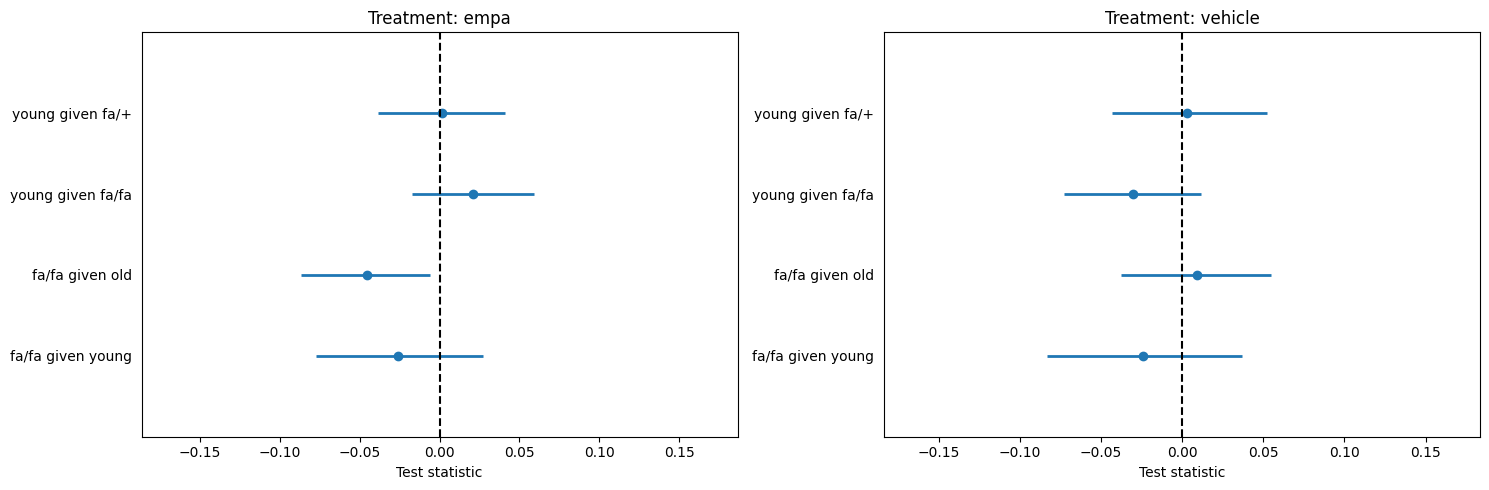

In [30]:
f, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0] = forestplot(axes[0], ts_empa);
axes[0].set_title("Treatment: empa");

axes[1] = forestplot(axes[1], ts_vehicle);
axes[1].set_title("Treatment: vehicle");

f.tight_layout()
f.savefig(PLOT_DIR / "ts_bp.png", bbox_inches="tight", dpi=200)